## Factores asociados a mortalidad intrahospitalaria

**Proyecto:** Avance 1 - Análisis de Datos e Inferencia Estadística  
**Integrantes:** Agustín Reyes & Matías Mouat  

**Preguntas de Investigación:**
1. ¿En qué medida la presencia de una causa de muerte secundaria actúa como un factor acelerador de la mortalidad en adultos en edad laboral (25-64 años)?

2. ¿Existe una correlación significativa entre los meses de invierno (junio-agosto) y un aumento en las defunciones por enfermedades del sistema respiratorio en comparación con otras causas?

3. ¿Existen diferencias estadísticamente significativas en la esperanza de vida observada (edad de defunción) entre géneros al segmentar por regiones de Chile durante el periodo 2023-2025?

4. ¿Difiere el perfil epidemiológico de mortalidad entre regiones?

5. ¿Qué causas generan mayor pérdida de vida productiva?


## 1. Introducción y Contexto

El presente estudio busca caracterizar los patrones de mortalidad en Chile tras la crisis sanitaria global.  
Según el reporte oficial, Chile experimentó un aumento del 4,0% en las defunciones durante 2024.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Configuración de estética visual limpia y geométrica para los gráficos
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.rcParams['figure.figsize'] = (10, 6)

# Ajuste de parámetros de visualización en Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Paso 1: Ingesta y Configuración del Entorno
Para empezar, se procedió a la carga del dataset oficial del DEIS en formato CSV. Debido a la naturaleza del archivo, fue necesario configurar la codificación en latin-1 y establecer el separador de punto y coma (;). Además, se ajustaron los parámetros de visualización en Pandas para permitir una inspección completa de los registros, facilitando así una primera aproximación al contenido del dataset.

In [8]:
# Carga de datos (Asegúrate de que el nombre del archivo coincida con tu ruta local)
ruta_archivo = "DEFUNCIONES_FUENTE_DEIS_2023_2026_04032026.csv"
df = pd.read_csv(ruta_archivo, encoding='latin-1', sep=';')

print(f"Dimensiones iniciales del dataset: {df.shape}")

Dimensiones iniciales del dataset: (394976, 27)


### Paso 2: Exploración Inicial y Clasificación de Variables
Después, se realizó una clasificación de las variables disponibles, priorizando aquellas de mayor relevancia epidemiológica para el estudio. En esta etapa, se descartaron variables que no aportaban valor directo al análisis, como el lugar de defunción o la estacionalidad, con el objetivo de mantener un enfoque claro. 

De esta forma, se trabajó principalmente con variables cualitativas como género, región y diagnóstico principal y secundario, junto con la variable cuantitativa de edad. Asimismo, se utilizaron funciones exploratorias como .info() y .head() para comprender la estructura de los datos e identificar posibles valores nulos.

In [9]:
# Seleccionar solo las variables de interés para aislar el ruido
columnas_relevantes = [
    'FECHA_DEF', 'EDAD_CANT', 'SEXO_NOMBRE', 'NOMBRE_REGION', 
    'GLOSA_CAPITULO_DIAG1', 'GLOSA_CAPITULO_DIAG2'
]
df = df[columnas_relevantes]

# Exploración de estructura y nulos
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 394976 entries, 0 to 394975
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   FECHA_DEF             394976 non-null  str  
 1   EDAD_CANT             394976 non-null  int64
 2   SEXO_NOMBRE           394976 non-null  str  
 3   NOMBRE_REGION         394920 non-null  str  
 4   GLOSA_CAPITULO_DIAG1  394971 non-null  str  
 5   GLOSA_CAPITULO_DIAG2  25462 non-null   str  
dtypes: int64(1), str(5)
memory usage: 18.1 MB


,FECHA_DEF,EDAD_CANT,SEXO_NOMBRE,NOMBRE_REGION,GLOSA_CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG2
0,2026-02-15,81,Hombre,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
1,2026-01-23,97,Mujer,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
2,2026-01-05,93,Hombre,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
3,2026-02-14,88,Hombre,Metropolitana de Santiago,"Enfermedades endocrinas, nutricionales y metab...",NaN
4,2026-01-05,89,Mujer,Metropolitana de Santiago,Enfermedades del sistema respiratorio,NaN


### Paso 3: Limpieza y Transformación de Datos (Data Cleaning)
Seguido de esto, se llevó a cabo el proceso de limpieza y transformación de los datos. En primer lugar, la variable de fecha de defunción fue convertida a formato datetime para permitir su manipulación adecuada. Luego, se aplicaron filtros de calidad, eliminando registros categóricos que no aportaban valor analítico, como la categoría “Ignorada” en la variable de región, y restringiendo la variable de género a las categorías “Hombre” y “Mujer”. 

Adicionalmente, se realizó ingeniería de características, creando la variable booleana TIENE_SECUNDARIA para identificar la presencia de comorbilidades, y se delimitó el análisis a la población en edad laboral activa, comprendida entre los 25 y 64 años.

In [ ]:
# Normalización Temporal y de Edad
df['FECHA_DEF'] = pd.to_datetime(df['FECHA_DEF'], errors='coerce')
df['EDAD_CANT'] = pd.to_numeric(df['EDAD_CANT'], errors='coerce')

# Filtros
df = df.dropna(subset=['FECHA_DEF', 'EDAD_CANT']) 
df = df[df['NOMBRE_REGION'] != 'Ignorada']
df = df[df['SEXO_NOMBRE'].isin(['Hombre', 'Mujer'])]

# Variable Booleana
df['TIENE_SECUNDARIA'] = df['GLOSA_CAPITULO_DIAG2'].notna()
df['AÑO'] = df['FECHA_DEF'].dt.year

# Delimitación a edad laboral activa (25 a 64 años)
# Usamos .copy() para crear un dataframe independiente
df_lab = df[(df['EDAD_CANT'] >= 25) & (df['EDAD_CANT'] <= 64)].copy()

print(f"Registros en edad laboral tras la limpieza: {df_lab.shape[0]}")

Registros en edad laboral tras la limpieza: 88646


### Paso 3.5: Impacto de Comorbilidades en la Mortalidad Laboral

C:\Users\Agustin\AppData\Local\Temp\ipykernel_25396\1748660572.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


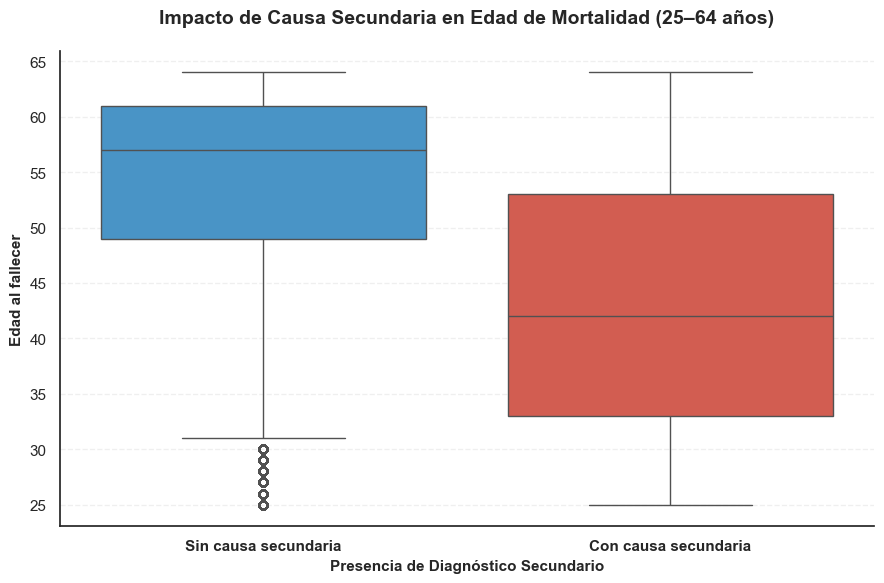

In [29]:
# Calcular las medias exactas para mostrarlas en el gráfico
media_sin = df_lab[df_lab['TIENE_SECUNDARIA'] == False]['EDAD_CANT'].mean()
media_con = df_lab[df_lab['TIENE_SECUNDARIA'] == True]['EDAD_CANT'].mean()

# Gráfico Boxplot
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=df_lab,
    x='TIENE_SECUNDARIA',
    y='EDAD_CANT',
    palette=['#3498db', '#e74c3c'], 
    
)

# Estética
plt.xticks([0,1], ['Sin causa secundaria', 'Con causa secundaria'], fontweight='bold', fontsize=11)
plt.ylabel("Edad al fallecer", fontweight='bold', fontsize=11)
plt.xlabel("Presencia de Diagnóstico Secundario", fontweight='bold', fontsize=11)
plt.title("Impacto de Causa Secundaria en Edad de Mortalidad (25–64 años)", fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Paso 4: Análisis Descriptivo y Perfil Epidemiológico
A continuación, se desarrolló el análisis descriptivo, segmentando el dataset en subconjuntos anuales para el período 2023–2026. Para cada uno de estos segmentos se calcularon medidas de tendencia central, como la media y la mediana, así como medidas de dispersión para la edad. 

Paralelamente, mediante operaciones de agrupamiento, se identificaron las principales causas de muerte por región, lo que permitió construir un perfil epidemiológico territorial.

,Media Edad,Mediana Edad,Desviación Estándar,Total Casos
AÑO,,,,
2023,52.00,55.0,10.49,28061
2024,52.06,55.0,10.42,28377
2025,52.13,55.0,10.34,27871
2026,51.94,55.0,10.50,4337


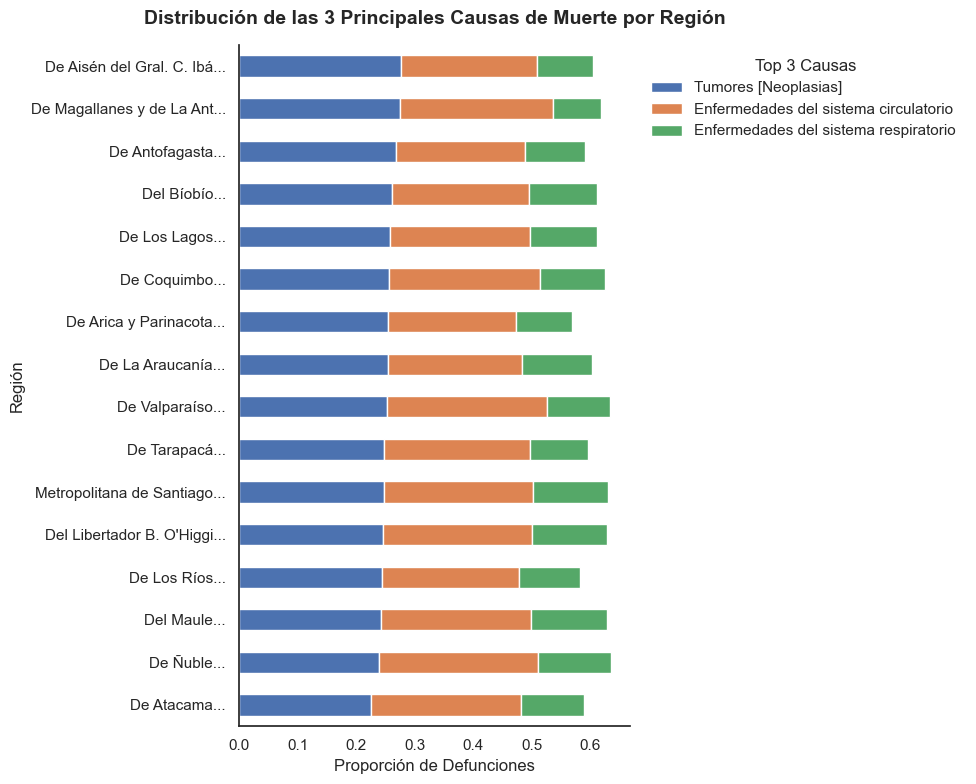

In [ ]:

# Medidas de tendencia central y dispersión por año
desc_anual = df_lab.groupby('AÑO')['EDAD_CANT'].agg(['mean', 'median', 'std', 'count']).round(2)
desc_anual.columns = ['Media Edad', 'Mediana Edad', 'Desviación Estándar', 'Total Casos']
display(desc_anual)

# Perfil Epidemiológico: Causa principal por región
perfil = df.groupby('NOMBRE_REGION')['GLOSA_CAPITULO_DIAG1'] \
           .value_counts(normalize=True).unstack()
perfil = perfil.drop(index='Ignorada', errors='ignore')

# Top 3 causas nacionales
top_3_causas = perfil.mean().sort_values(ascending=False).index[:3]
perfil_top3 = perfil[top_3_causas]

# Ordenar
causa_principal = top_3_causas[0]
perfil_top3 = perfil_top3.sort_values(by=causa_principal, ascending=True)

# Acortar nombres
perfil_top3.index = perfil_top3.index.str.replace("Región de ", "")
perfil_top3.index = perfil_top3.index.str.slice(0, 25) + '...'
colores = ['#4c72b0', '#dd8452', '#55a868']

fig, ax = plt.subplots(figsize=(10, 8))
perfil_top3.plot(
    kind='barh',
    stacked=True,
    color=colores,
    edgecolor='white',
    linewidth=1,
    ax=ax
)
ax.set_title("Distribución de las 3 Principales Causas de Muerte por Región",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Proporción de Defunciones")
ax.set_ylabel("Región")
plt.legend(
    title="Top 3 Causas",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Paso 4.5: Análisis de Estacionalidad y Enfermedades Respiratorias

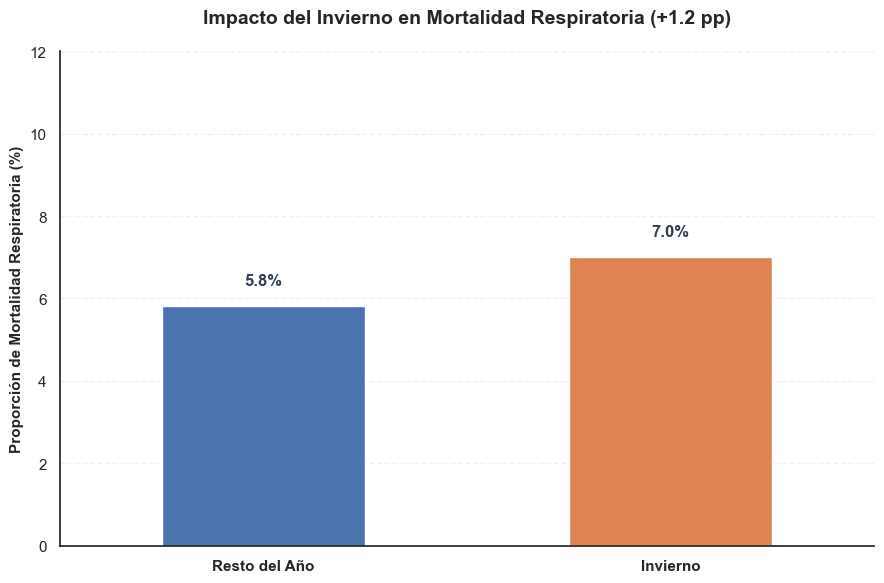

In [ ]:
# Pregunta 2
# Extraer el mes de defunción
df_lab['MES'] = df_lab['FECHA_DEF'].dt.month

# Definir Invierno (Meses 6, 7 y 8)
df_lab['ES_INVIERNO'] = df_lab['MES'].isin([6, 7, 8])

# Definir si la causa fue respiratoria (Devuelve un booleano True/False)
df_lab['ES_RESPIRATORIO'] = df_lab['GLOSA_CAPITULO_DIAG1'].str.contains('respiratorio', case=False, na=False)

# Calcular el porcentaje de defunciones respiratorias por estación
# Alsobre una variable booleana (True=1, False=0) para obtener la proporción directamente.
temp = df_lab.groupby('ES_INVIERNO')['ES_RESPIRATORIO'].mean() * 100

# Calcular la diferencia 
diff = temp[True] - temp[False]
plt.figure(figsize=(9, 6))


ax = temp.plot(kind='bar', color=['#4c72b0', '#dd8452'])
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.xticks([0, 1], ['Resto del Año', 'Invierno'], rotation=0, fontweight='bold', fontsize=11)
plt.ylabel("Proporción de Mortalidad Respiratoria (%)", fontweight='bold', fontsize=11)
plt.xlabel("") 
plt.ylim(0, temp.max() + 5) 

# Añadir Etiquetas exactas sobre cada barra
for i, v in enumerate(temp):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', color='#2c3e50', fontweight='bold')

plt.title(f"Impacto del Invierno en Mortalidad Respiratoria (+{diff:.1f} pp)", fontweight='bold', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Paso 5: Análisis de la Brecha de Género a Nivel Regional
Después, se abordó el análisis de la brecha de género a nivel regional. Para ello, se agruparon los datos por región y sexo, calculando la edad promedio de fallecimiento en cada grupo. A partir de estos resultados, se estimó la diferencia absoluta entre mujeres y hombres, lo que permitió visualizar la magnitud de esta brecha y su variabilidad a lo largo del país.

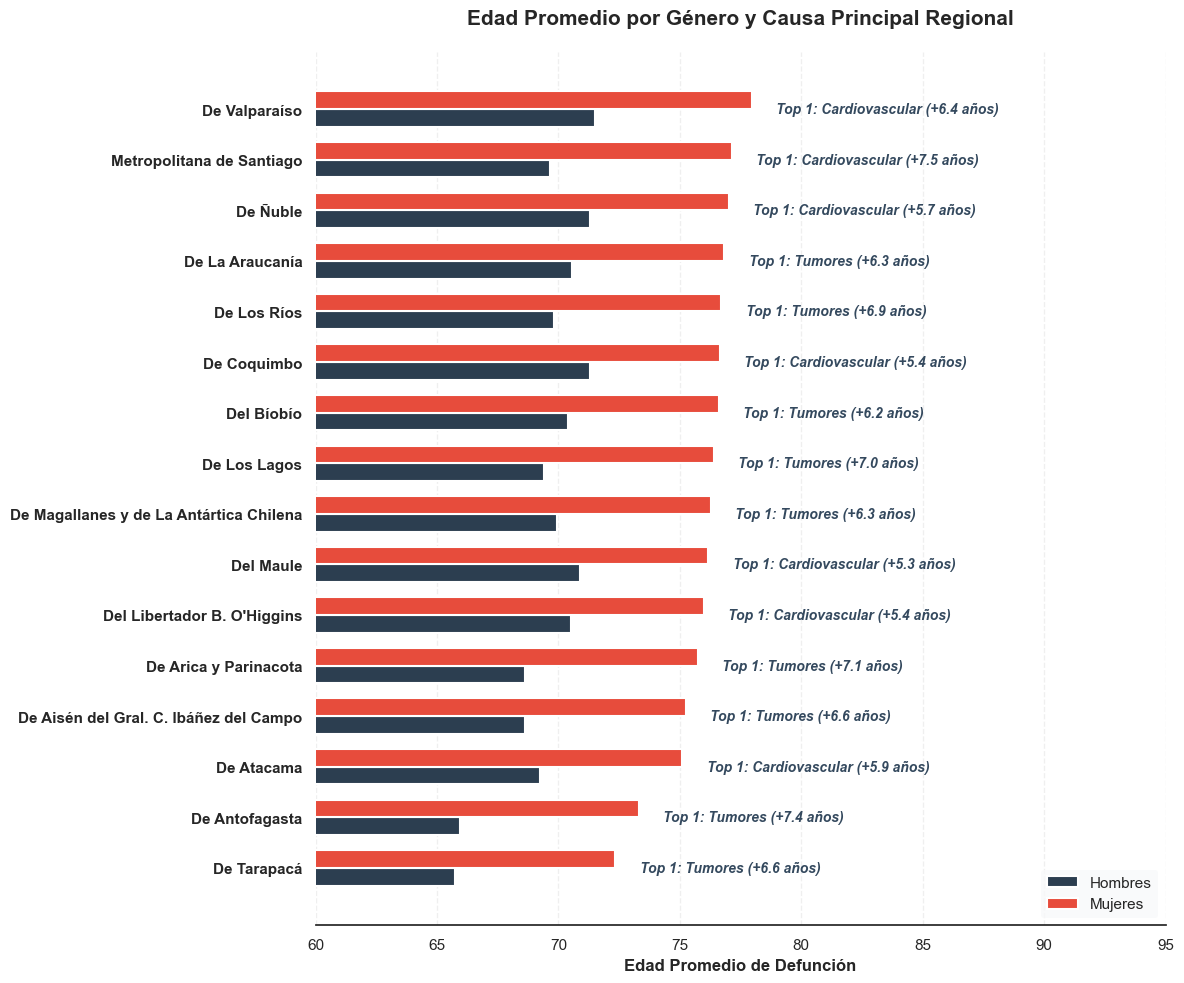

In [ ]:
# Pregunta 3
# Filtro base para limpiar 'Ignorada'
df_limpio = df[df['NOMBRE_REGION'] != 'Ignorada']

# Calcular las edades promedio
longevidad = df_limpio.groupby(['NOMBRE_REGION', 'SEXO_NOMBRE'])['EDAD_CANT'].mean().unstack()
longevidad = longevidad[['Hombre', 'Mujer']]
longevidad['diff'] = longevidad['Mujer'] - longevidad['Hombre']

# Encontrar la causa principal por región
causa_principal = df_limpio.groupby('NOMBRE_REGION')['GLOSA_CAPITULO_DIAG1'].agg(lambda x: x.value_counts().index[0])
longevidad['Causa_Top'] = causa_principal

# Ordenar por la edad promedio de las mujeres para darle un flujo visual
longevidad = longevidad.sort_values('Mujer', ascending=True)


sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})
fig, ax = plt.subplots(figsize=(12, 10))

y = np.arange(len(longevidad.index))
alto_barra = 0.35  


ax.barh(y - alto_barra/2, longevidad['Hombre'], alto_barra, label='Hombres', color='#2c3e50', edgecolor='white', linewidth=1.5)
ax.barh(y + alto_barra/2, longevidad['Mujer'], alto_barra, label='Mujeres', color='#e74c3c', edgecolor='white', linewidth=1.5)

# 5. Añadir anotaciones (Causa Top y Brecha de años)
for i, (idx, row) in enumerate(longevidad.iterrows()):
    causa = row['Causa_Top']
    if 'circulatorio' in causa.lower():
        causa_texto = 'Cardiovascular'
    elif 'tumores' in causa.lower() or 'neoplasias' in causa.lower():
        causa_texto = 'Tumores'
    elif 'respiratorio' in causa.lower():
        causa_texto = 'Respiratorio'
    else:
        causa_texto = causa[:15] + '...'


    max_val = max(row['Hombre'], row['Mujer'])
    

    ax.text(max_val + 1, i, f"Top 1: {causa_texto} (+{row['diff']:.1f} años)", 
            va='center', ha='left', fontsize=10, color='#34495e', 
            fontstyle='italic', fontweight='bold')


ax.set_yticks(y)
ax.set_yticklabels(longevidad.index, fontweight='bold', fontsize=11)
ax.set_xlabel("Edad Promedio de Defunción", fontweight='bold')
ax.set_title("Edad Promedio por Género y Causa Principal Regional", fontweight='bold', fontsize=15, pad=20)

ax.set_xlim(60, 95) 

ax.legend(loc='lower right', frameon=True, fontsize=11, facecolor='#f8f9fa', edgecolor='none')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Paso 6: Cálculo de Años de Vida Potencialmente Perdidos (AVPP)
Finalmente, se calculó el indicador de Años de Vida Potencialmente Perdidos (AVPP), restando la edad de defunción al umbral teórico de vida laboral (65 años). Los resultados fueron agrupados por capítulo de diagnóstico, lo que permitió identificar aquellas causas que generan mayor impacto en términos de pérdida de vida productiva. 

Es importante destacar que se decidió mantener los valores atípicos correspondientes a edades muy bajas, ya que representan casos reales de mortalidad prematura y no errores en los datos.

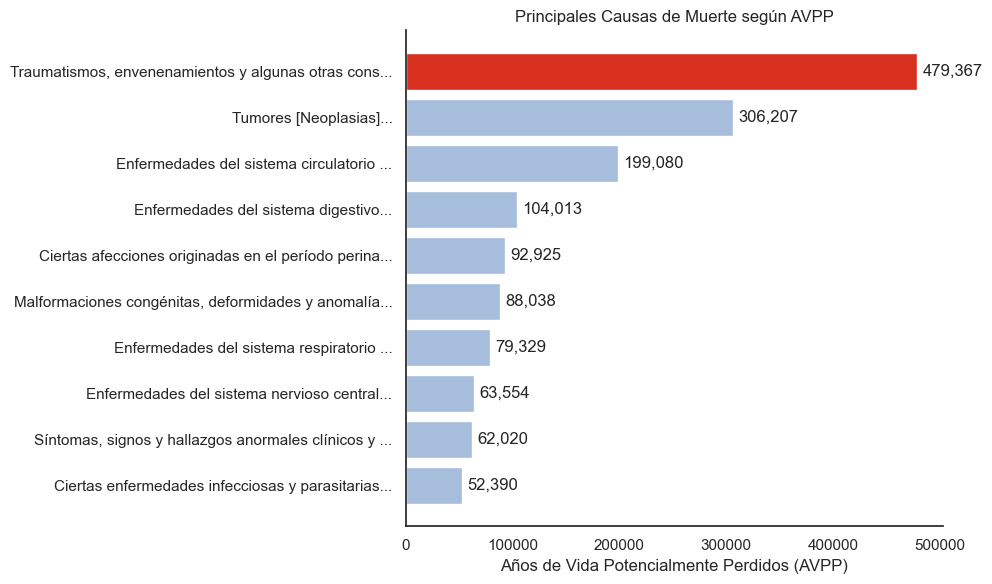

In [22]:
#Pregunta 5
# Crear AVPP
df['AVPP'] = df['EDAD_CANT'].apply(lambda x: 65 - x if x < 65 else 0)

impacto = df.groupby('GLOSA_CAPITULO_DIAG1')['AVPP'] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10)
impacto = impacto.sort_values(ascending=True)

# acortar nombres
impacto.index = impacto.index.str.slice(0, 50) + '...'

plt.figure(figsize=(10, 6))

colors = ['#a6bddb'] * len(impacto)
colors[-1] = '#d7301f'

plt.barh(impacto.index, impacto.values, color=colors)

for i, v in enumerate(impacto):
    plt.text(v + 5000, i, f"{int(v):,}", va='center')

plt.xlabel("Años de Vida Potencialmente Perdidos (AVPP)")
plt.title("Principales Causas de Muerte según AVPP")
plt.tight_layout()
plt.show()

### Paso 7: Modelado Predictivo (Regresión Lineal)
En la siguiente etapa, se implementó un modelo de regresión lineal con el objetivo de analizar la evolución del volumen de mortalidad. Este modelo fue entrenado utilizando los totales históricos disponibles agrupados mensualmente, permitiendo proyectar la tendencia de defunciones hacia periodos futuros y observar posibles comportamientos crecientes o estables.

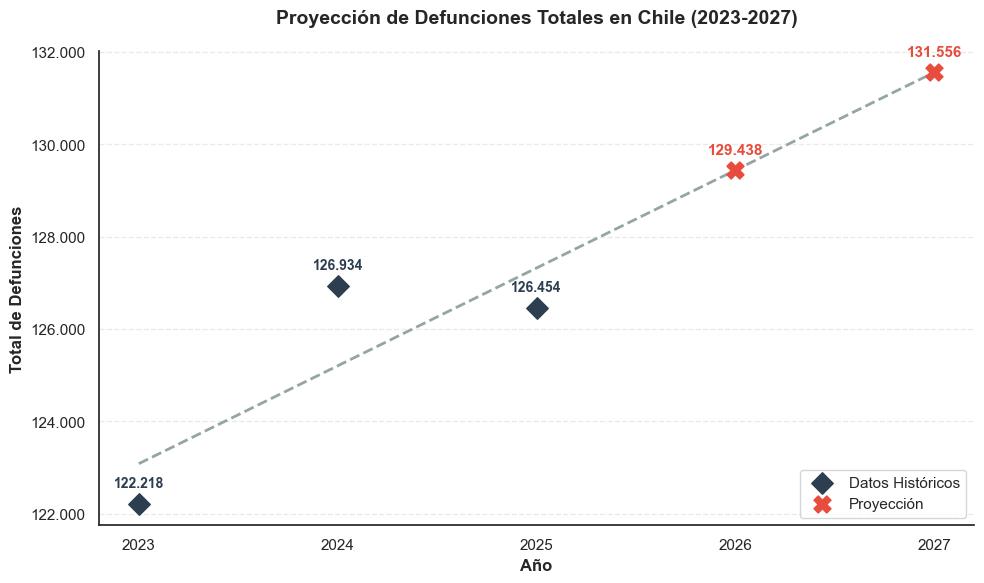

In [21]:

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
anos_reales = np.array([2023, 2024, 2025]).reshape(-1, 1)
totales_reales = np.array([122218, 126934, 126454])


modelo = LinearRegression()
modelo.fit(anos_reales, totales_reales)
anos_pred = np.array([2026, 2027]).reshape(-1, 1)
totales_pred = modelo.predict(anos_pred)

fig, ax = plt.subplots(figsize=(10, 6))
anos_linea = np.array([2023, 2024, 2025, 2026, 2027]).reshape(-1, 1)
ax.plot(anos_linea, modelo.predict(anos_linea), color='#95a5a6', linestyle='--', linewidth=2, zorder=1)
ax.scatter(anos_reales, totales_reales, color='#2c3e50', s=120, marker='D', label='Datos Históricos', zorder=2)
ax.scatter(anos_pred, totales_pred, color='#e74c3c', s=150, marker='X', label='Proyección', zorder=2)

def formato_miles(x):
    return f"{int(x):,}".replace(',', '.')

for i in range(len(anos_reales)):
    ax.annotate(formato_miles(totales_reales[i]), 
                (anos_reales[i][0], totales_reales[i]), 
                textcoords="offset points", xytext=(0,12), ha='center', 
                color='#2c3e50', weight='bold', fontsize=10)

for i in range(len(anos_pred)):
    ax.annotate(formato_miles(totales_pred[i]), 
                (anos_pred[i][0], totales_pred[i]), 
                textcoords="offset points", xytext=(0,12), ha='center', 
                color='#e74c3c', weight='bold', fontsize=11)

ax.set_title('Proyección de Defunciones Totales en Chile (2023-2027)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Total de Defunciones', fontsize=12, fontweight='bold')
ax.set_xticks([2023, 2024, 2025, 2026, 2027])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: formato_miles(x)))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()